# Novella Bind Score — Exploratory Data Analysis

Covers:
1. Target & class distribution
2. Temporal patterns (lifecycle, early divergence)
3. Event-level analysis (type mix, email engagement, cadence)
4. Agent-level bind rates
5. Feature feasibility at `t ∈ {0, 7, 30}`

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
os.makedirs('output', exist_ok=True)
os.makedirs('output/eda_figures', exist_ok=True)

LABEL_COLORS = {0: '#5B8DB8', 1: '#E07B54'}
LABEL_NAMES  = {0: 'Not Bound', 1: 'Bound'}

In [2]:
subs   = pd.read_csv('data/features_submissions.csv', parse_dates=['createdDate', 'resolvedDate'])
events = pd.read_csv('data/features_events.csv',      parse_dates=['event_date'])

# days since creation at resolution
subs['resolution_days'] = (subs['resolvedDate'] - subs['createdDate']).dt.total_seconds() / 86400

print('Submissions:', subs.shape)
print('Events:     ', events.shape)
subs.head(3)

Submissions: (881, 6)
Events:      (17211, 5)


,submissionId,createdDate,resolvedDate,agentEmail,label,resolution_days
0,1,2020-01-01 00:00:00,2020-02-11 08:19:16,1@gmail.com,0,41.346713
1,2,2020-01-01 04:08:26,2020-01-15 03:01:10,2@gmail.com,0,13.953287
2,3,2020-01-01 05:54:25,2020-01-09 01:41:13,3@gmail.com,0,7.824167


---
## 1. Target & Class Distribution

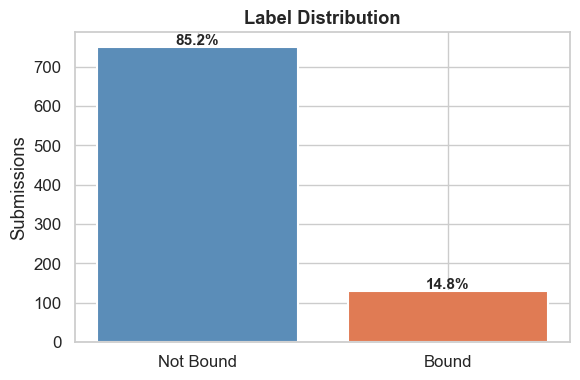

label
0    751
1    130


In [3]:
label_counts = subs['label'].value_counts().sort_index()
label_pct    = label_counts / len(subs) * 100

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    [LABEL_NAMES[k] for k in label_counts.index],
    label_counts.values,
    color=[LABEL_COLORS[k] for k in label_counts.index],
    edgecolor='white', linewidth=1.5
)
for bar, pct in zip(bars, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Label Distribution', fontweight='bold')
ax.set_ylabel('Submissions')

plt.tight_layout()
plt.savefig('output/eda_figures/01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(label_counts.to_string())

---
## 2. Resolution Time Distribution

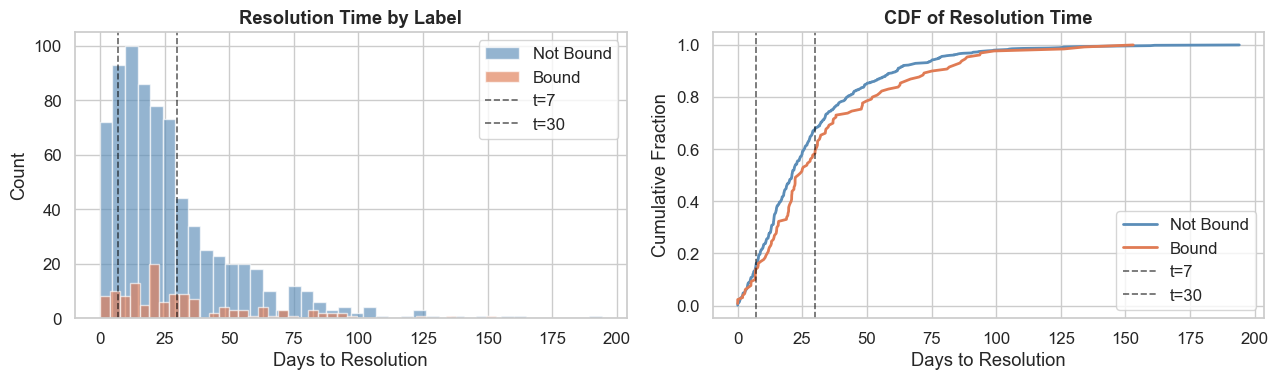

       count  mean   std  min   25%   50%   75%    max
label                                                 
0      751.0  28.0  25.4  0.0  11.1  21.0  36.5  194.0
1      130.0  33.4  29.0  0.0  13.9  23.7  46.9  153.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, grp in subs.dropna(subset=['resolution_days']).groupby('label'):
    axes[0].hist(grp['resolution_days'], bins=40, alpha=0.65,
                 label=LABEL_NAMES[label], color=LABEL_COLORS[label], edgecolor='white')

for t in [7, 30]:
    axes[0].axvline(t, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label=f't={t}')

axes[0].set_xlabel('Days to Resolution')
axes[0].set_ylabel('Count')
axes[0].set_title('Resolution Time by Label', fontweight='bold')
axes[0].legend()

# CDF
for label, grp in subs.dropna(subset=['resolution_days']).groupby('label'):
    sorted_days = np.sort(grp['resolution_days'])
    cdf = np.arange(1, len(sorted_days)+1) / len(sorted_days)
    axes[1].plot(sorted_days, cdf, label=LABEL_NAMES[label], color=LABEL_COLORS[label], linewidth=2)

for t in [7, 30]:
    axes[1].axvline(t, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label=f't={t}')

axes[1].set_xlabel('Days to Resolution')
axes[1].set_ylabel('Cumulative Fraction')
axes[1].set_title('CDF of Resolution Time', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/eda_figures/02_resolution_time.png', dpi=150, bbox_inches='tight')
plt.show()

print(subs.groupby('label')['resolution_days'].describe().round(1))

---
## 3. Data Leakage Audit

Check whether any events occur **after** `resolvedDate`.  
Such events cannot be used as features at any prediction time `t`.

In [5]:
ev = events.merge(subs[['submissionId', 'createdDate', 'resolvedDate', 'label']], on='submissionId')
ev['days_since_creation'] = (ev['event_date'] - ev['createdDate']).dt.total_seconds() / 86400
ev['days_to_resolution']  = (ev['resolvedDate'] - ev['createdDate']).dt.total_seconds() / 86400
ev['after_resolution']    = ev['days_since_creation'] > ev['days_to_resolution']

leakage_summary = (
    ev.groupby('event_type')['after_resolution']
      .agg(['sum', 'count'])
      .rename(columns={'sum': 'after_resolved', 'count': 'total'})
)
leakage_summary['pct_after_resolved'] = (leakage_summary['after_resolved'] / leakage_summary['total'] * 100).round(1)
print(leakage_summary.sort_values('pct_after_resolved', ascending=False))

                after_resolved  total  pct_after_resolved
event_type                                               
EMAIL_INBOUND                0   6355                 0.0
EMAIL_OUTBOUND               0   9712                 0.0
QUOTE_RECEIVED               0   1144                 0.0


---
## 4. Event Activity Over Time — Do Bound Submissions Diverge Early?

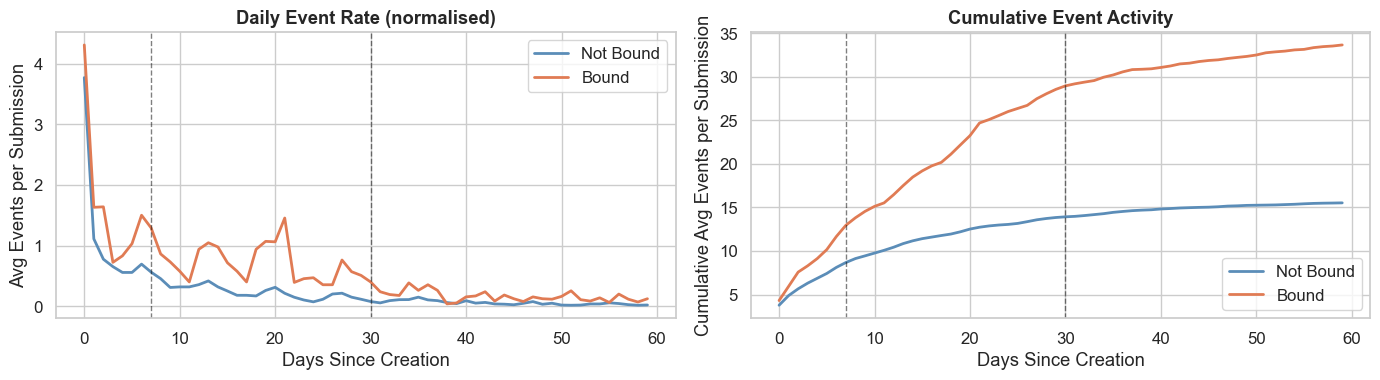

In [6]:
# Only events up to day 60 (enough to capture t=30 story)
ev_early = ev[ev['days_since_creation'].between(0, 60)].copy()
ev_early['day_bucket'] = ev_early['days_since_creation'].astype(int)

daily = (
    ev_early.groupby(['label', 'day_bucket'])
            .size()
            .reset_index(name='event_count')
)

# normalise by number of submissions per label so we compare per-submission rates
n_per_label = subs['label'].value_counts()
daily['events_per_submission'] = daily.apply(
    lambda r: r['event_count'] / n_per_label[r['label']], axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# daily rate
for label, grp in daily.groupby('label'):
    axes[0].plot(grp['day_bucket'], grp['events_per_submission'],
                 label=LABEL_NAMES[label], color=LABEL_COLORS[label], linewidth=2)
for t in [7, 30]:
    axes[0].axvline(t, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Days Since Creation')
axes[0].set_ylabel('Avg Events per Submission')
axes[0].set_title('Daily Event Rate (normalised)', fontweight='bold')
axes[0].legend()

# cumulative
daily_sorted = daily.sort_values('day_bucket')
for label, grp in daily_sorted.groupby('label'):
    cum = grp.set_index('day_bucket')['events_per_submission'].cumsum()
    axes[1].plot(cum.index, cum.values,
                 label=LABEL_NAMES[label], color=LABEL_COLORS[label], linewidth=2)
for t in [7, 30]:
    axes[1].axvline(t, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Days Since Creation')
axes[1].set_ylabel('Cumulative Avg Events per Submission')
axes[1].set_title('Cumulative Event Activity', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/eda_figures/03_event_activity_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Event Type Mix by Label

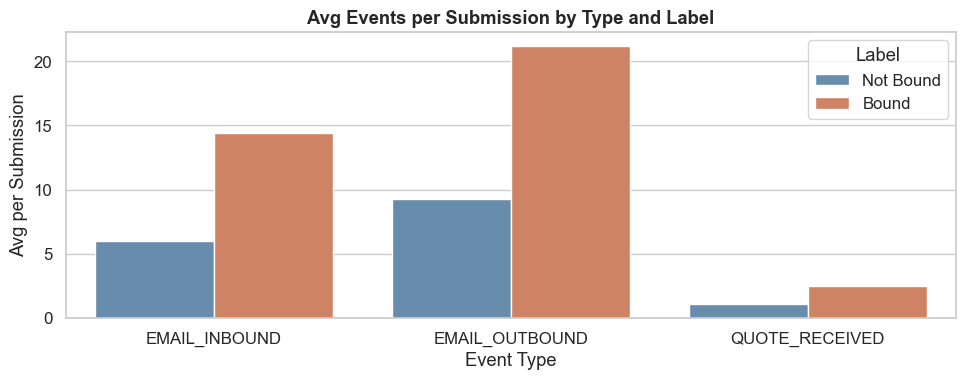

label_name      Bound  Not Bound
event_type                      
EMAIL_INBOUND   14.41       5.97
EMAIL_OUTBOUND  21.22       9.26
QUOTE_RECEIVED   2.49       1.09


In [7]:
type_label = (
    ev.groupby(['label', 'event_type'])
      .size()
      .reset_index(name='count')
)
type_label['per_submission'] = type_label.apply(
    lambda r: r['count'] / n_per_label[r['label']], axis=1
)
type_label['label_name'] = type_label['label'].map(LABEL_NAMES)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=type_label, x='event_type', y='per_submission',
    hue='label_name', palette=list(LABEL_COLORS.values()), ax=ax
)
ax.set_title('Avg Events per Submission by Type and Label', fontweight='bold')
ax.set_xlabel('Event Type')
ax.set_ylabel('Avg per Submission')
ax.legend(title='Label')

plt.tight_layout()
plt.savefig('output/eda_figures/04_event_type_mix.png', dpi=150, bbox_inches='tight')
plt.show()

print(type_label.pivot(index='event_type', columns='label_name', values='per_submission').round(2))

---
## 6. Email Engagement: Char Count & Attachment Count

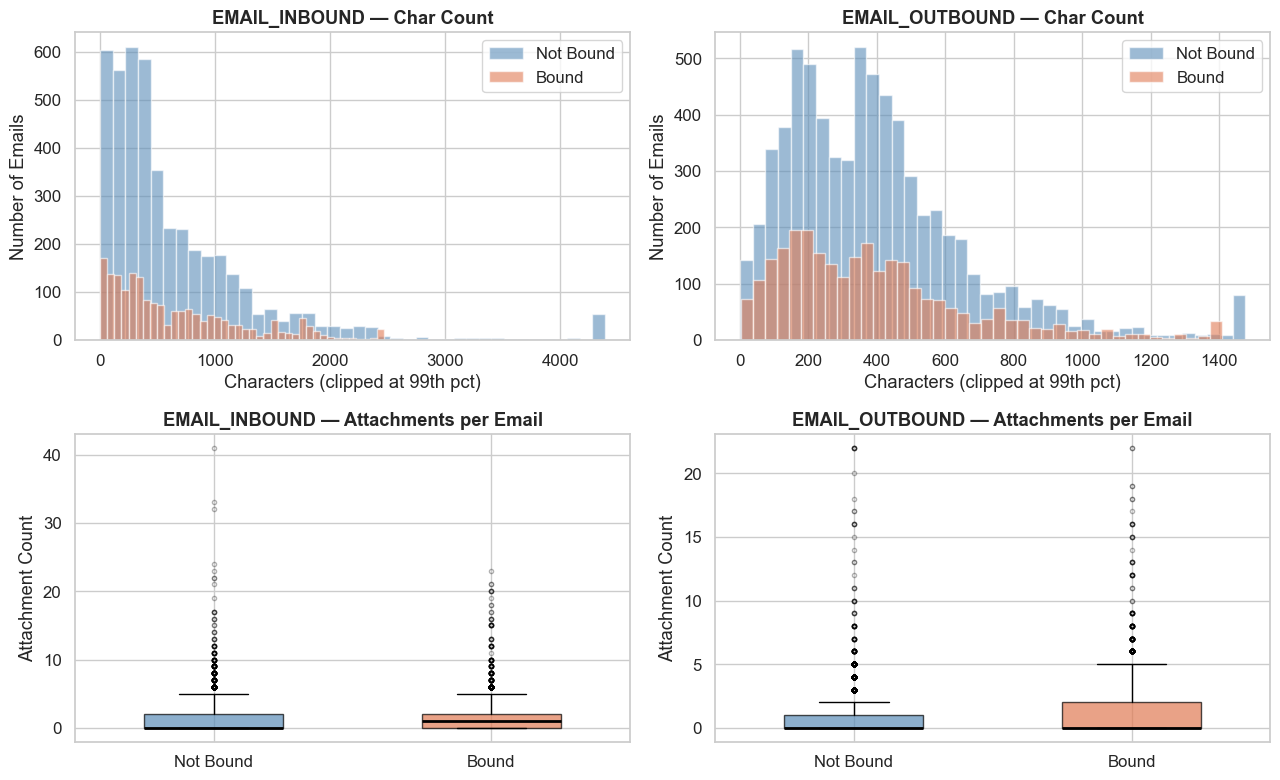

                     email_char_count                                    \
                                count   mean     std  min    25%    50%   
event_type     label                                                      
EMAIL_INBOUND  0               4482.0  703.0  1395.9  1.0  211.2  411.0   
               1               1873.0  690.8  1174.7  1.0  205.0  459.0   
EMAIL_OUTBOUND 0               6954.0  406.3   352.1  1.0  196.0  359.0   
               1               2758.0  399.0   303.7  2.0  179.0  344.0   

                                     email_attachment_count                 \
                        75%      max                  count mean  std  min   
event_type     label                                                         
EMAIL_INBOUND  0      875.0  38573.0                 4482.0  1.2  2.5  0.0   
               1      974.0  43650.0                 1873.0  1.8  3.0  0.0   
EMAIL_OUTBOUND 0      517.0  11630.0                 6954.0  0.7  1.5  0.0   
      

In [8]:
email_ev = ev[ev['event_type'].isin(['EMAIL_INBOUND', 'EMAIL_OUTBOUND'])].copy()
email_ev['label_name'] = email_ev['label'].map(LABEL_NAMES)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for col_idx, direction in enumerate(['EMAIL_INBOUND', 'EMAIL_OUTBOUND']):
    subset = email_ev[email_ev['event_type'] == direction]

    # char count — histogram
    for label, grp in subset.groupby('label'):
        axes[0, col_idx].hist(
            grp['email_char_count'].clip(upper=grp['email_char_count'].quantile(0.99)),
            bins=40, alpha=0.6, label=LABEL_NAMES[label],
            color=LABEL_COLORS[label], edgecolor='white'
        )
    axes[0, col_idx].set_title(f'{direction} — Char Count', fontweight='bold')
    axes[0, col_idx].set_xlabel('Characters (clipped at 99th pct)')
    axes[0, col_idx].set_ylabel('Number of Emails')
    axes[0, col_idx].legend()

    # attachment count — box plot (shows full distribution, no negative-bar issue)
    data_by_label = [
        subset[subset['label'] == lbl]['email_attachment_count'].values
        for lbl in [0, 1]
    ]
    bp = axes[1, col_idx].boxplot(
        data_by_label,
        labels=[LABEL_NAMES[0], LABEL_NAMES[1]],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=3, alpha=0.3, linestyle='none'),
        widths=0.5
    )
    for patch, color in zip(bp['boxes'], LABEL_COLORS.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1, col_idx].set_title(f'{direction} — Attachments per Email', fontweight='bold')
    axes[1, col_idx].set_ylabel('Attachment Count')

plt.tight_layout()
plt.savefig('output/eda_figures/05_email_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

print(email_ev.groupby(['event_type', 'label'])[['email_char_count', 'email_attachment_count']].describe().round(1))

---
## 7. Response Cadence: Inbound/Outbound Ratio & Reply Speed

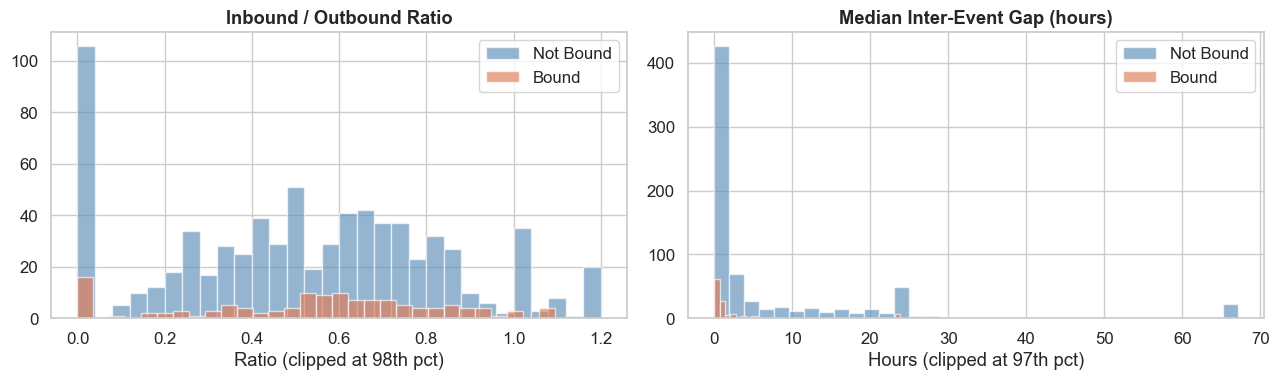

       count  mean   std  min  25%  50%  75%     max
label                                               
0      733.0  14.2  96.8  0.0  0.4  1.1  9.2  2357.6
1      130.0   3.7   7.8  0.0  0.4  0.7  2.4    46.4


In [9]:
# per-submission inbound/outbound counts
direction_counts = (
    email_ev.groupby(['submissionId', 'event_type'])
            .size()
            .unstack(fill_value=0)
            .reset_index()
)
direction_counts.columns.name = None

for col in ['EMAIL_INBOUND', 'EMAIL_OUTBOUND']:
    if col not in direction_counts.columns:
        direction_counts[col] = 0

direction_counts['io_ratio'] = (
    direction_counts['EMAIL_INBOUND'] /
    (direction_counts['EMAIL_OUTBOUND'] + 1)   # +1 avoids div-by-zero
)
direction_counts = direction_counts.merge(subs[['submissionId', 'label']], on='submissionId')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ratio distribution
for label, grp in direction_counts.groupby('label'):
    axes[0].hist(
        grp['io_ratio'].clip(upper=grp['io_ratio'].quantile(0.98)),
        bins=30, alpha=0.65, label=LABEL_NAMES[label],
        color=LABEL_COLORS[label], edgecolor='white'
    )
axes[0].set_title('Inbound / Outbound Ratio', fontweight='bold')
axes[0].set_xlabel('Ratio (clipped at 98th pct)')
axes[0].legend()

# inter-event gap (time between consecutive events per submission)
ev_sorted = ev.sort_values(['submissionId', 'event_date'])
ev_sorted['prev_event_date'] = ev_sorted.groupby('submissionId')['event_date'].shift(1)
ev_sorted['gap_hours'] = (
    (ev_sorted['event_date'] - ev_sorted['prev_event_date'])
    .dt.total_seconds() / 3600
)

gap_per_sub = (
    ev_sorted.dropna(subset=['gap_hours'])
             .groupby(['submissionId', 'label'])['gap_hours']
             .median()
             .reset_index()
)

for label, grp in gap_per_sub.groupby('label'):
    axes[1].hist(
        grp['gap_hours'].clip(upper=grp['gap_hours'].quantile(0.97)),
        bins=35, alpha=0.65, label=LABEL_NAMES[label],
        color=LABEL_COLORS[label], edgecolor='white'
    )
axes[1].set_title('Median Inter-Event Gap (hours)', fontweight='bold')
axes[1].set_xlabel('Hours (clipped at 97th pct)')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/eda_figures/06_cadence.png', dpi=150, bbox_inches='tight')
plt.show()

print(gap_per_sub.groupby('label')['gap_hours'].describe().round(1))

---
## 8. Agent-Level Bind Rate

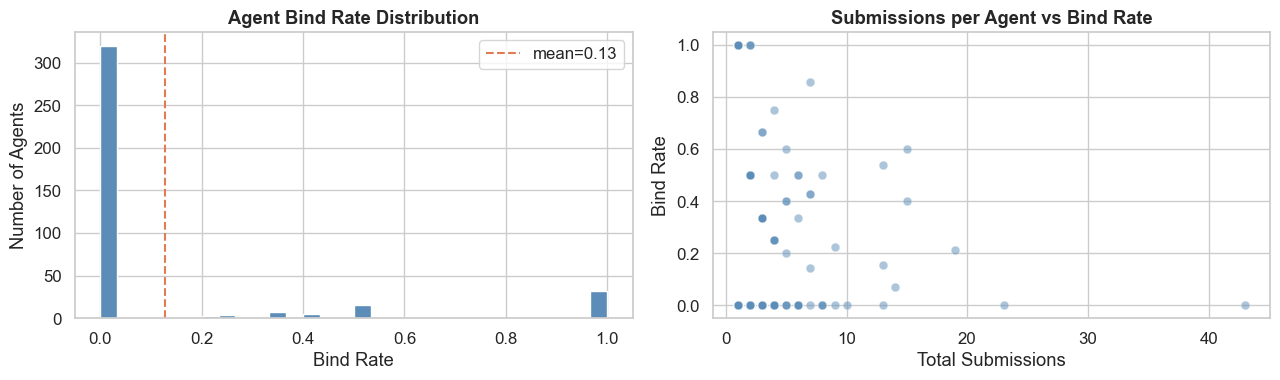

Agents with only 1 submission: 243 / 397
        total   bound  bind_rate
count  397.00  397.00     397.00
mean     2.22    0.33       0.13
std      3.25    0.93       0.30
min      1.00    0.00       0.00
25%      1.00    0.00       0.00
50%      1.00    0.00       0.00
75%      2.00    0.00       0.00
max     43.00    9.00       1.00


In [10]:
agent_stats = (
    subs.groupby('agentEmail')
        .agg(total=('label', 'count'), bound=('label', 'sum'))
        .reset_index()
)
agent_stats['bind_rate'] = agent_stats['bound'] / agent_stats['total']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# bind rate distribution across agents
axes[0].hist(agent_stats['bind_rate'], bins=30, color='#5B8DB8', edgecolor='white')
axes[0].axvline(agent_stats['bind_rate'].mean(), color='#E07B54',
                linestyle='--', linewidth=1.5, label=f'mean={agent_stats["bind_rate"].mean():.2f}')
axes[0].set_title('Agent Bind Rate Distribution', fontweight='bold')
axes[0].set_xlabel('Bind Rate')
axes[0].set_ylabel('Number of Agents')
axes[0].legend()

# volume vs bind rate scatter
sc = axes[1].scatter(
    agent_stats['total'], agent_stats['bind_rate'],
    alpha=0.5, s=40, c='#5B8DB8', edgecolors='white', linewidths=0.5
)
axes[1].set_title('Submissions per Agent vs Bind Rate', fontweight='bold')
axes[1].set_xlabel('Total Submissions')
axes[1].set_ylabel('Bind Rate')

plt.tight_layout()
plt.savefig('output/eda_figures/07_agent_bind_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Agents with only 1 submission: {(agent_stats['total']==1).sum()} / {len(agent_stats)}")
print(agent_stats.describe().round(2))

---
## 9. Feature Feasibility at t ∈ {0, 7, 30}

For each time window, check: *what fraction of submissions have at least one observable event?*

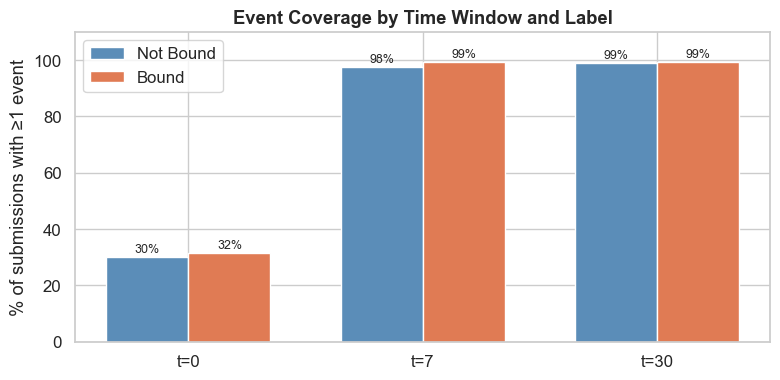

 t     label  submissions  with_events  coverage_pct
 0 Not Bound          751          227     30.226365
 0     Bound          130           41     31.538462
 7 Not Bound          751          733     97.603196
 7     Bound          130          129     99.230769
30 Not Bound          751          744     99.067909
30     Bound          130          129     99.230769


In [11]:
T_VALUES = [0, 7, 30]

rows = []
for t in T_VALUES:
    ev_t = ev[ev['days_since_creation'] <= t]
    for label in [0, 1]:
        subs_with_label = subs[subs['label'] == label]['submissionId']
        covered = ev_t[ev_t['submissionId'].isin(subs_with_label)]['submissionId'].nunique()
        rows.append({'t': t, 'label': LABEL_NAMES[label],
                     'submissions': len(subs_with_label), 'with_events': covered,
                     'coverage_pct': 100 * covered / len(subs_with_label)})

feasibility = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(T_VALUES))
width = 0.35
for i, label_name in enumerate([LABEL_NAMES[0], LABEL_NAMES[1]]):
    grp = feasibility[feasibility['label'] == label_name]
    bars = ax.bar(x + i*width, grp['coverage_pct'].values, width,
                  label=label_name, color=list(LABEL_COLORS.values())[i],
                  edgecolor='white')
    for bar, val in zip(bars, grp['coverage_pct'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width/2)
ax.set_xticklabels([f't={t}' for t in T_VALUES])
ax.set_ylabel('% of submissions with ≥1 event')
ax.set_title('Event Coverage by Time Window and Label', fontweight='bold')
ax.set_ylim(0, 110)
ax.legend()

plt.tight_layout()
plt.savefig('output/eda_figures/08_feature_feasibility.png', dpi=150, bbox_inches='tight')
plt.show()

print(feasibility.to_string(index=False))

---
## 10. Feature Correlation with Label (Raw Signal Ranking)

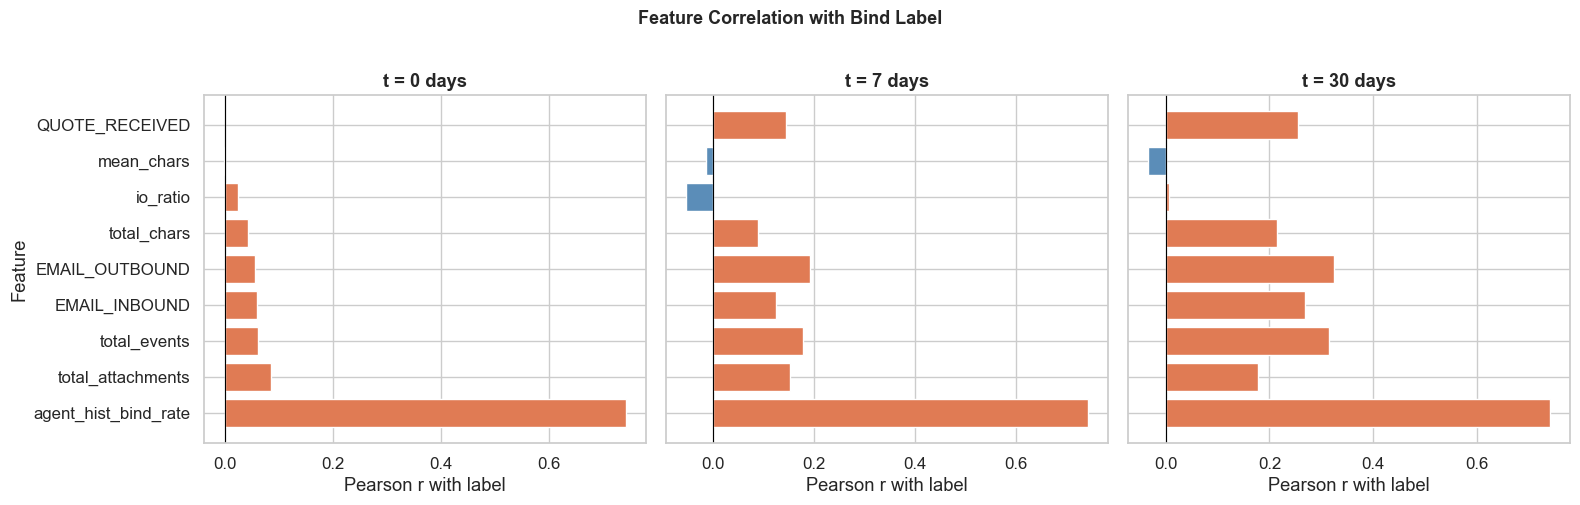

In [12]:
def compute_features_at_t(t):
    """Compute candidate raw features for all submissions at cutoff day t."""
    ev_t = ev[ev['days_since_creation'] <= t]

    total_events = ev_t.groupby('submissionId').size().rename('total_events')

    type_counts = (
        ev_t.groupby(['submissionId', 'event_type'])
            .size()
            .unstack(fill_value=0)
    )

    email_agg = (
        ev_t[ev_t['event_type'].isin(['EMAIL_INBOUND','EMAIL_OUTBOUND'])]
            .groupby('submissionId')
            .agg(
                total_chars=('email_char_count', 'sum'),
                mean_chars=('email_char_count', 'mean'),
                total_attachments=('email_attachment_count', 'sum'),
            )
    )

    inbound_count  = type_counts.get('EMAIL_INBOUND',  pd.Series(0, index=type_counts.index))
    outbound_count = type_counts.get('EMAIL_OUTBOUND', pd.Series(0, index=type_counts.index))
    io_ratio = (inbound_count / (outbound_count + 1)).rename('io_ratio')

    agent_bind_rate = subs.set_index('submissionId')['agentEmail'].map(
        subs.groupby('agentEmail')['label'].mean()
    ).rename('agent_hist_bind_rate')

    feat = (
        subs[['submissionId', 'label']]
            .set_index('submissionId')
            .join(total_events)
            .join(type_counts)
            .join(email_agg)
            .join(io_ratio)
            .join(agent_bind_rate)
            .fillna(0)
    )
    return feat


fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, t in zip(axes, T_VALUES):
    feat = compute_features_at_t(t)
    feature_cols = [c for c in feat.columns if c != 'label']
    corr = feat[feature_cols].corrwith(feat['label']).sort_values(key=abs, ascending=False)
    colors = ['#E07B54' if v > 0 else '#5B8DB8' for v in corr.values]
    ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f't = {t} days', fontweight='bold')
    ax.set_xlabel('Pearson r with label')
    if ax == axes[0]:
        ax.set_ylabel('Feature')

plt.suptitle('Feature Correlation with Bind Label', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/eda_figures/09_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

Key findings to carry into feature engineering and modelling:

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Class imbalance | Use AUC-PR / balanced accuracy; consider class weighting |
| 2 | Most resolutions occur well within 30 days | `t=30` window captures most of the lifecycle |
| 3 | Event activity diverges early for bound submissions | Early prediction is feasible |
| 4 | Leakage check | Some event types may post-date resolution — filter by `days_since_creation ≤ t` |
| 5 | Email engagement & io_ratio differ by label | Strong feature candidates |
| 6 | Agent historical bind rate | Useful prior — but beware train/test leakage; compute from training fold only |
| 7 | Coverage drops at t=0 | Null-handling or fallback needed for cold-start submissions |